# Simulating Beam from CSV Data

In [1]:
import pandas as pd
import numpy as np
import random
%matplotlib inline
import matplotlib.pyplot as plt
from itertools import product
from random import shuffle
from math import floor, ceil
import glob
from IPython.display import display
from PIL import Image
from collections import defaultdict
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

In [14]:
radius = 0.2 #in mm
file_path = "fort.110_0.dat" #name of the the file
x_hole = np.arange(-15, 16, 3) #change these values to encompass the entire screen, test by including holes that should have no particles
y_hole = np.arange(27, -28, -9)
holes = list(product(x_hole, y_hole))
# -12.3814 12.2775 -12.3638 12.3408 -24.7564 24.6638 -6.24147 6.17563
hole_rows = [[(x, y) for x in x_hole] for y in y_hole]
L = 0.05 #drift distance
output_name = 'Selected.csv' #name of output file after fit function
column_names = ["Column1", "Column2", "Column3", "Column4", "Column5", "Column6", "Column7", "Column8"]

In [3]:
def fit(r, array, holes, L): 
    fit_particles = []
    for i in range(len(holes)):
        fitted = (array[:, 0] - holes[i][0])*(array[:, 0] - holes[i][0]) + (array[:, 2] - holes[i][1])*(array[:, 2] - holes[i][1]) < r*r
        sampled_temp = array[fitted]
        sampled_temp[:, 0] = sampled_temp[:, 0] + sampled_temp[:, 1] * L
        sampled_temp[:, 2] = sampled_temp[:, 2] + sampled_temp[:, 3] * L
        if len(sampled_temp) > 0:
            hole_coords = np.full((sampled_temp.shape[0], 2), holes[i])  
            sampled_temp = np.hstack([sampled_temp, hole_coords]) #adds the hole_coord values
            fit_particles.append(sampled_temp)
    return fit_particles

In [4]:
def read_csv(file_path, column_names):
    # Read the data using pd.read_csv(), specifying the delimiter and handling negative numbers
    df = pd.read_csv(file_path, delimiter=r"\s+", header=None)
    # Replace "-.number" with "0.number"
    df = df.replace(to_replace=r'^-\.', value='0.', regex=True)
    df.columns = column_names
    return df

In [69]:
def heat_map(x, y, bins):  #
    xmin = np.min(x) - 2
    xmax = np.max(x) + 2
    ymin = np.min(y) - 2
    ymax = np.max(y) + 2
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins, range = [[xmin, xmax], [ymin, ymax]])
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    density_data = np.vstack([X.ravel(), Y.ravel(), heatmap.T.ravel()]).T
    plt.figure(figsize = (12, 12))
    plt.imshow(heatmap.T, origin='lower', cmap='jet', interpolation='None')
#     save_image = np.flipud(heatmap.T)
#     save_image.save
    plt.imsave('20250415.png', np.flipud(heatmap.T), cmap='jet') 
    plt.colorbar()
    plt.show()
    return density_data, heatmap.T

In [126]:
def create_boundaries(real_array, Nx, xmin, width, dx, Ny, ymin, height, dy):
    x, y, p = real_array[:, 0], real_array[:, 1], real_array[:, 2]
#     Nx = int((xmax-xmin)/width)
#     Ny = int((ymax-ymin)/height)
#     print(Nx, Ny)
    boundaries = [[None for _ in range(Nx)] for _ in range(Ny)]
    grouped_points = [[[] for _ in range(Nx)] for _ in range(Ny)]

    for i in range(Nx):
        x_min_temp = xmin + i * (width + dx)
        for j in range(Ny):
            y_min_temp = ymin + j * (height + dy)
            row_index = Ny - 1 - j
            boundaries[row_index][i] = (x_min_temp, y_min_temp, width, height)

    for j in range(Ny):  # Iterate over rows
        for i in range(Nx):  # Iterate over columns
            x_min, y_min, width, height = boundaries[j][i]
            for xi, yi, pi in zip(x, y, p):
                if x_min <= xi <= x_min + width and y_min <= yi <= y_min + height and pi > 0:
                    grouped_points[j][i].append((xi, yi, pi))
                
    fig, ax = plt.subplots(figsize=(15, 10))
    #ax.scatter(x, y, c = p, cmap = 'jet')
    for row in boundaries:
        for (x_min, y_min, width, height) in row:  
            rect = Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    plt.title("Real Coordinates with Boundaries")
#     plt.xlim(0, 14)
#     plt.ylim(-10, 5)
    plt.show()
    return grouped_points, boundaries

In [7]:
def normalize_rows(rows, holes):
    target_height = len(holes)
    target_width = len(holes[0])

    src_height = len(rows)
    src_width = max(len(row) for row in rows)
    print(src_height, src_width)

    # Compute padding needed to center rows inside holes
    pad_top = (target_height - src_height) // 2
    pad_left = (target_width - src_width) // 2

    # Create new grid
    normalized = [[[] for _ in range(target_width)] for _ in range(target_height)]
    print(pad_top, pad_left)
    # Fill in the data
    for i, row in enumerate(rows):
        for j, cell in enumerate(row):
            new_i = i + pad_top
            new_j = j + pad_left
            if 0 <= new_i < target_height and 0 <= new_j < target_width:
                normalized[new_i][new_j] = cell

    return normalized

In [8]:
def calc_angles(holes, circles, L): #update this to do a mask based method 
#     angle_x_arrays = []
#     angle_y_arrays = []
#     x_assoc = []
#     y_assoc = []
    total = []
    for i in range(len(circles)):
        for j in range(len(circles[i])):
            if len(circles[i][j]) > 0:
#                 print(holes[i][j])
#                 print(circles[i][j])
                for k in range(len(circles[i][j])):
                    angle_x = (circles[i][j][k][0] - holes[i][j][0]) / L 
                    angle_y = (circles[i][j][k][1] - holes[i][j][1]) / L
                    temp = circles[i][j][k] + (angle_x, angle_y) #append in such a way that it can be sliced, ie do not use a tuple
#                     angle_x_arrays.append(angle_x) #update straight into array rather than create seperate lists 
#                     angle_y_arrays.append(angle_y)
#                     x_assoc.append(circles[i][j][k][0])
#                     y_assoc.append(circles[i][j][k][1])
                    total.append(temp)
    return total # circles

In [9]:
df = read_csv(file_path, column_names)

In [10]:
array = df.values #gets rid of the dimensionality of the dataframe

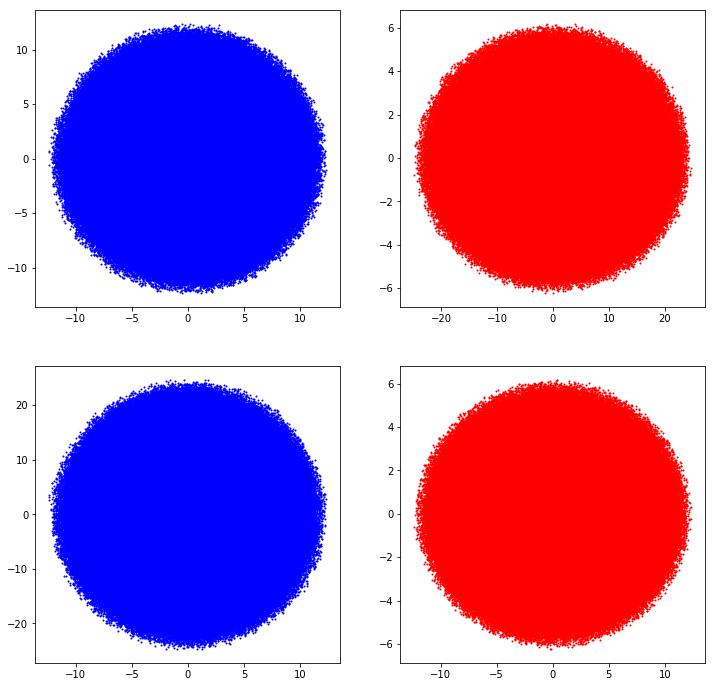

In [11]:
fig = plt.figure(figsize = (12, 12))
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(array[:, 0], array[:, 1], s = 1, color = 'blue')
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(array[:, 2], array[:, 3], s = 1, color = 'red')
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(array[:, 0], array[:, 2], s= 1, color = 'blue')
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(array[:, 1], array[:, 3], s = 1, color = 'red')
# ax.set_xticks(major_ticks)
# plt.set_yticks(major_ticks)
# plt.ylim(-20, 200000)
# ax.grid()
plt.show()

In [15]:
#without drift selection
select_no_drift = fit(radius, array, holes, 0)

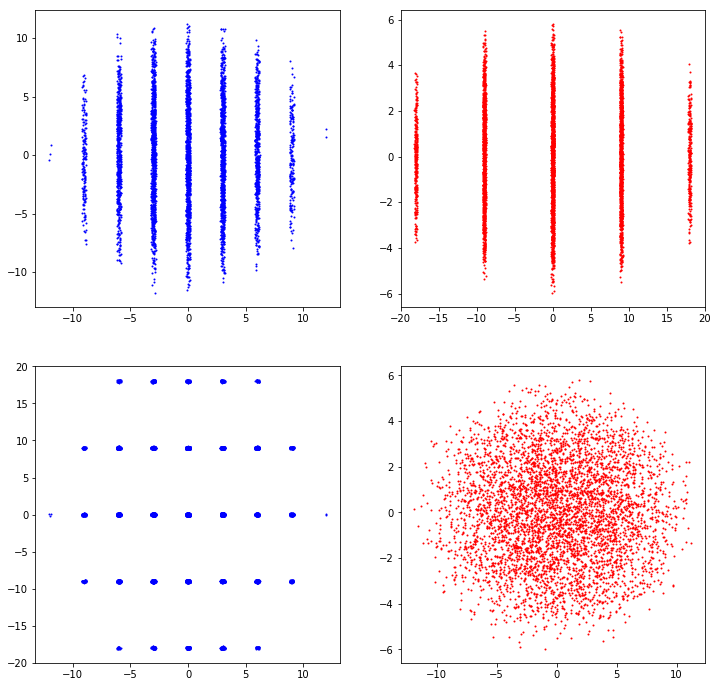

In [16]:
x_no_drift = []
y_no_drift = []
xprime_no_drift = []
yprime_no_drift = []
for i in range(len(select_no_drift)):
    for j in range(len(select_no_drift[i])):
        x_no_drift.append(select_no_drift[i][j][0])
        xprime_no_drift.append(select_no_drift[i][j][1])
        y_no_drift.append(select_no_drift[i][j][2])
        yprime_no_drift.append(select_no_drift[i][j][3])
fig = plt.figure(figsize = (12, 12))
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x_no_drift, xprime_no_drift, s = 1, color = 'blue')
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(y_no_drift, yprime_no_drift, s = 1, color = 'red')
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(x_no_drift, y_no_drift, s= 1, color = 'blue')
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(xprime_no_drift, yprime_no_drift, s = 1, color = 'red')
# ax.set_xticks(major_ticks)
# plt.set_yticks(major_ticks)
# plt.ylim(-20, 200000)
# ax.grid()
plt.show()

In [17]:
selection = fit(radius, array, holes, L)  #add a tag for associated hole  

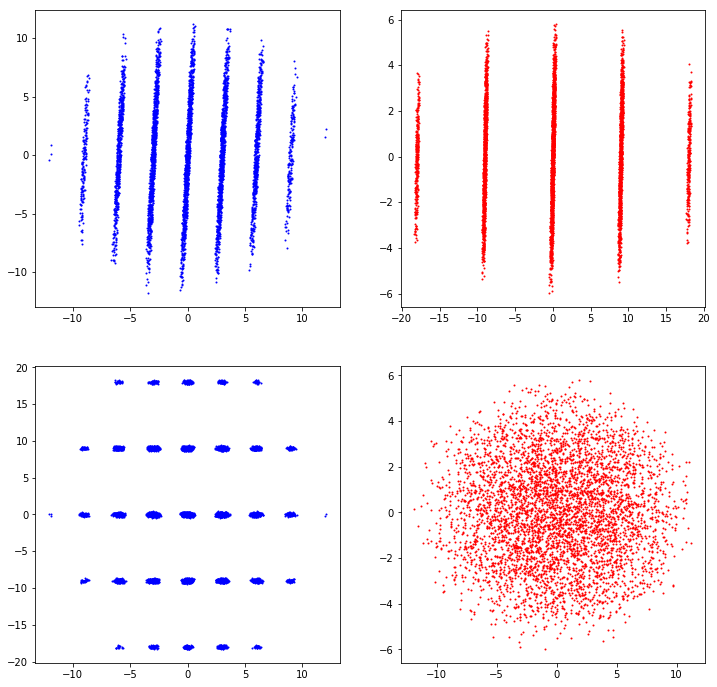

In [18]:
x_drift = []
y_drift = []
xprime_drift = []
yprime_drift = []
for i in range(len(selection)):
    for j in range(len(selection[i])):
        x_drift.append(selection[i][j][0])
        xprime_drift.append(selection[i][j][1])
        y_drift.append(selection[i][j][2])
        yprime_drift.append(selection[i][j][3])
fig = plt.figure(figsize = (12, 12))
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x_drift, xprime_drift, s = 1, color = 'blue')
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(y_drift, yprime_drift, s = 1, color = 'red')
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(x_drift, y_drift, s= 1, color = 'blue')
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(xprime_drift, yprime_drift, s = 1, color = 'red')
# ax.set_xticks(major_ticks)
# plt.set_yticks(major_ticks)
# plt.ylim(-20, 200000)
# ax.grid()
plt.show()

In [90]:
print(np.max(x_drift) - np.min(x_drift))
print(np.max(y_drift) - np.min(y_drift))

24.106911600000004
36.6367965


In [ ]:
12.052181000000001 -12.054730600000001
18.3089995 -18.327797

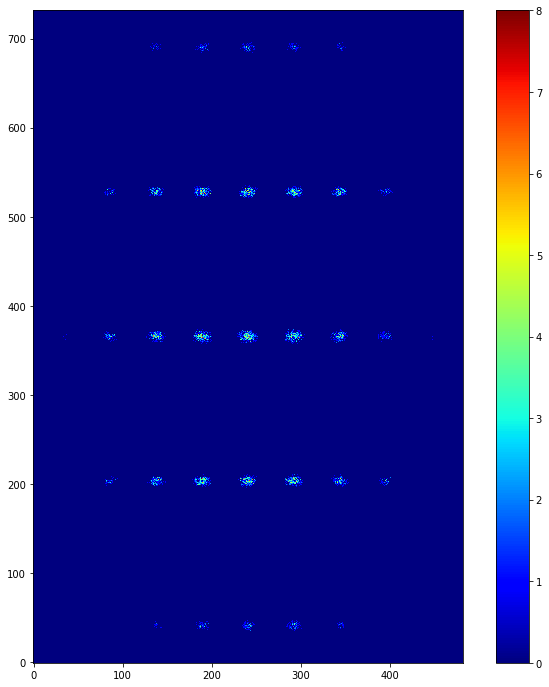

In [76]:
xstep = 0.05 #mm/pixel
ystep = 0.05 #mm/pixel
binx = int((np.max(x_drift)-np.min(x_drift))/xstep)
biny = int((np.max(y_drift)-np.min(y_drift))/ystep)
bins = np.array([binx, biny])
density, heatmap_data = heat_map(x_drift, y_drift, bins) #make the density return 2D

In [92]:
delta_x = np.max(x_drift) - np.min(x_drift)
delta_y = np.max(y_drift) - np.min(y_drift)

In [93]:
xmin = np.min(x_drift) * (delta_x+4)/delta_x
xmax = np.max(x_drift) * (delta_x+4)/delta_x
ymin = np.min(y_drift) * (delta_y+4)/delta_y
ymax = np.max(y_drift) * (delta_y+4)/delta_y
height, width = heatmap_data.shape

In [95]:
x_1D = np.linspace(xmin, xmax, width)
y_1D = np.linspace(ymin, ymax, height)
X_2D, Y_2D = np.meshgrid(x_1D, y_1D)
density_data = np.vstack([X_2D.ravel(), Y_2D.ravel(), heatmap_data.ravel()]).T

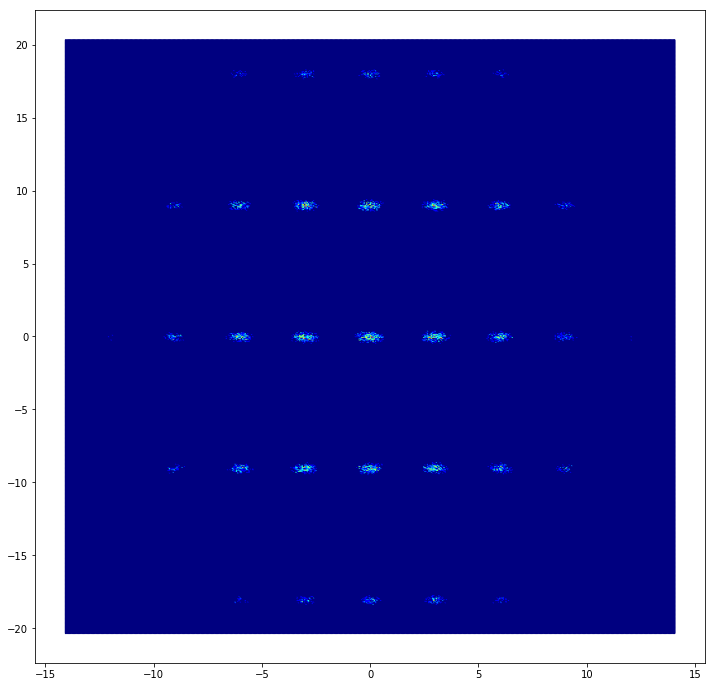

In [106]:
plt.figure(figsize = (12, 12))
plt.scatter(density_data[:, 0], density_data[:, 1], c = density_data[:, 2], cmap = 'jet', s = 1)
plt.show()

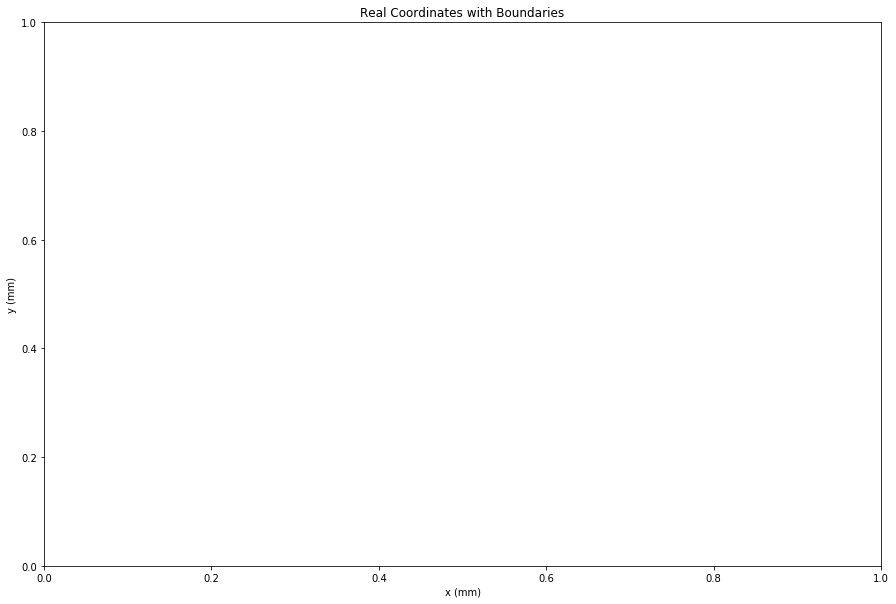

In [127]:
xmin = -14
xmax = 14
ymin = -21
ymax = 21
Nx = 9
Ny = 5
width = (xmax - xmin)/Nx
height = (ymax - ymin)/Ny
dx = 0.01
dy = 0.01
group, boundary = create_boundaries(density_data, Nx, xmin, width, dx, Ny,ymin, height, dy)

In [118]:
group_array = np.array(group)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.


In [124]:
def create_boundaries_2(real_array, Nx, xmin, width, dx, Ny, ymin, height, dy):
    flattened = np.array(real_array.tolist(), dtype = float).reshape(-1, 3)
    x = flattened[:, 0]
    y = flattened[:, 1]
    p = flattened[:, 2]
    x_edges = xmin + np.arange(Nx) * (width + dx)
    y_edges = ymin + np.arange(Ny) * (height + dy)
    x_edge_grid, y_edge_grid = np.meshgrid(x_edges, y_edges)
    #create the boundaries using np.stack because we can get those values from the inputs
    boundaries = np.stack((x_edge_grid, y_edge_grid, np.full_like(x_edge_grid, width), np.full_like(y_edge_grid, height)), axis = -1) #np.full_like fills an array with the same value to be the same size as the first argument
    grouped_points = np.empty((Ny, Nx), dtype = object) #need to set dtype to object so it can store lists
    grouped_points[:, :] = [[[] for _ in range(Nx)] for _ in range(Ny)] #do not save as lists save as arrays 
    x_grid_index = ((x-xmin)//(width + dx)).astype(int) #for each value which associated index do they have
    y_grid_index = ((y-ymin)//(height + dy)).astype(int) #ensure they are integers or else they can not be appened
    #creating masks based on index rather than true position
    masks = ((x_grid_index >= 0) & (x_grid_index < Nx) &
        (y_grid_index >= 0) & (y_grid_index < Ny) &
        (p > 0)) #if a particle belongs to in between grids set it to 0
    true_y_index = Ny - 1 - y_grid_index
    for xi, yi, pi, i, j in zip(x[masks], y[masks], p[masks], x_grid_index[masks], true_y_index[masks]):
        grouped_points[j][i].append((xi, yi, pi)) 
    #plotting
    fig, ax = plt.subplots(figsize=(15, 10))
    #ax.scatter(x, y, c = p, cmap = 'jet')
    ax.scatter(x, y, s =0.5)
    for j in range(Ny):
        for i in range(Nx):
            x_min, y_min, w, h = boundaries[j, i]
            rect = Rectangle((x_min, y_min), w, h, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect) #find a way to have this plot without the data itself
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    plt.title("Real Coordinates with Boundaries")
    plt.show()
    return grouped_points, boundaries

In [1]:
group_2, boundary_2 = create_boundaries_2(density_data, Nx, xmin, width, dx, Ny,ymin, height, dy)

NameError: name 'create_boundaries_2' is not defined

In [ ]:
normalized = normalize_rows(group, hole_rows)

In [ ]:
total = calc_angles(hole_rows, normalized, 30)

In [ ]:
x_cal = []
y_cal = []
p_cal = []
xp_cal = []
yp_cal = []
for i in range(len(total)):
    x_cal.append(total[i][0])
    y_cal.append(total[i][1])
    p_cal.append(total[i][2])
    xp_cal.append(total[i][3]*1000)
    yp_cal.append(total[i][4]*1000)

In [ ]:
fig = plt.figure(figsize = (12, 12))
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x_cal, xp_cal, s = 1, color = 'blue')
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(y_cal, yp_cal, s = 1, color = 'red')
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(x_cal, y_cal, s= 1, color = 'blue')
ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(xp_cal, yp_cal, s = 1, color = 'red')
# ax.set_xticks(major_ticks)
# plt.set_yticks(major_ticks)
# plt.ylim(-20, 200000)
# ax.grid()
plt.show()

In [ ]:
x = np.array(x_cal)
y = np.array(y_cal)
z = np.array(p_cal)
X, Y = np.meshgrid(np.linspace(min(x), max(x), len(np.unique(x))), 
                    np.linspace(min(y), max(y), len(np.unique(y))))
Z = np.zeros(X.shape)
for i in range(len(x)):
    xi = np.searchsorted(X[0], x[i])
    yi = np.searchsorted(Y[:, 0], y[i])
    Z[yi, xi] = z[i]
fig = go.Figure(data=[go.Surface(x=X, y=Y, z=Z)])
fig.update_traces(contours_z=dict(show=True, usecolormap=True,
                                    highlightcolor="limegreen", project_z=True))
fig.update_layout(
#     title=title, 
    scene=dict(
#         xaxis_title=xlabel,
#         yaxis_title=ylabel,
#         zaxis_title=zlabel,
#         xaxis=dict(range=x_range),
#         yaxis=dict(range=y_range),
#         zaxis=dict(range=z_range),
        camera=dict(eye=dict(x=1.87, y=0.88, z=-0.64))
    ),
    width=800, 
    height=800,
    margin=dict(l=65, r=50, b=65, t=90)
)
fig.show()

In [ ]:
plt.scatter(x, xprime, c = p, cmap = 'jet', s = 1)
plt.colorbar()
plt.xlabel('x (mm)')
plt.ylabel("x' (rad)")
plt.show() #check the number of x values being found

In [ ]:
plt.scatter(y, yprime, c = p, cmap = 'jet', s = 1)
plt.colorbar()
plt.xlabel('y (mm)')
plt.ylabel("y' (mrad)")
plt.show()